In [2]:
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_excel(r"../data/Housing.xlsx")

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,yes,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
#select feature and target
#linear regression so only one feature
X=df[['area']] #feature is input
y=df['price'] #target is output #if y is 2d use ravel to convert 2d into 1d

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
model= LinearRegression() #create model

In [8]:
model.fit(X_train,y_train) #train the model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[40.67]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.007e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [9]:
#make prediction
y_pred=model.predict(X_test)

In [10]:
result = pd.DataFrame({
    "Actual Price":y_test.values,
    "Predicted Price":y_pred
})
print(result)

   Actual Price  Predicted Price
0       9800000     1.030581e+07
1       9100000     1.031598e+07
2      13300000     1.037374e+07


In [11]:
#print equation values #for our own purpose
print("\nSlope (Coefficient):",model.coef_[0])
print("Intercept:",model.intercept_)


Slope (Coefficient): 40.67462530019181
Intercept: 10071931.849554067


In [12]:
#evaluate model
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print("\nMean squared error:",mse) #lower this better model
print("R^2 Score:",r2) #higher this better model


Mean squared error: 3432487638819.6367
R^2 Score: -0.01686598911707482


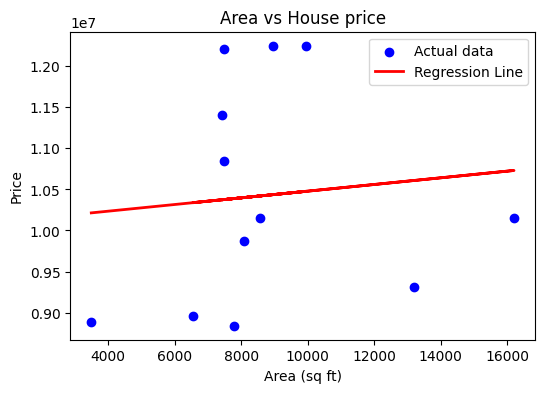

In [13]:
#plot training data
plt.figure(figsize=(6,4))
plt.scatter(X_train,y_train,
            color='blue',
            label='Actual data')
plt.plot(X_train,
         model.predict(X_train),
         color='red',
         linewidth=2,
         label='Regression Line')
plt.title("Area vs House price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.legend()
plt.show()

In [14]:
df.shape
#dont have proper dataset

(15, 13)

In [15]:
#predict new house price
new_house=[[5000]]
predicted_price=model.predict(new_house) #as 1d so uska 0 index ka value yk
print(f"\nPredicted Price for 5000 sq. ft house = ${predicted_price[0]:,.2f}")


Predicted Price for 5000 sq. ft house = $10,275,304.98


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


MULTILINEAR REGRESSION

In [16]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,yes,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [23]:
#select features and target
features=df[['area','bedrooms','bathrooms','stories','parking']]
target=df['price']

In [24]:
X_train,X_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=42)

In [25]:
mlr_model=LinearRegression()

In [26]:
mlr_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 136.7 , 77560.69, 464751.84,-330793.4 ,1088397.28]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['area','bedrooms','bathrooms','stories','parking']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.771e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [27]:
predicted_price=mlr_model.predict(X_test)

In [28]:
comparison=pd.DataFrame({
    "Actual Price":y_test.values,
    "Predicted Price":predicted_price
})
print(comparison)

   Actual Price  Predicted Price
0       9800000     8.484747e+06
1       9100000     1.081122e+07
2      13300000     1.020979e+07


In [29]:
#Display coefficients
print("Intercept:",mlr_model.intercept_)
coefficients=pd.DataFrame({
    "Feature":features.columns,
    "Coefficient":mlr_model.coef_
})
print(coefficients)

Intercept: 6771290.822394925
     Feature   Coefficient
0       area  1.367038e+02
1   bedrooms  7.756069e+04
2  bathrooms  4.647518e+05
3    stories -3.307934e+05
4    parking  1.088397e+06


In [30]:
#evaluate the model
mse=mean_squared_error(y_test,predicted_price)
r2=r2_score(y_test,predicted_price)

print("\nMean squared error:",mse) #lower this better model
print("R^2 Score:",r2) #higher this better model


Mean squared error: 4735845584503.836
R^2 Score: -0.402982562887904


In [ ]:
#polynomial regression
#logistic regression
#ridge regression